# Qiskit Fall Fest 2023

![QFF Logo](images/QFF-logo.png)

## Challenge 9: Variational Quantum Algorothm

#### 여기까지 오신 분들, 정말 대단합니다! 이번 챌린지에서는<br>
* Variational quantum algorithm의 Pipeline
* 매개변수화된 양자 회로 설계
* QAOA를 이용한 Maxcut problem 최적화  
#### 에 대해 배우게 될 것입니다. <br>


##### 해밀토니안, 선형대수, Graph 구조에 대한 사전지식이 반드시 있어야 합니다.
인공신경망 (Neural Network), 기계학습 (Machine Learning)을 알고 계신다면 VQA를 이해하는 데에 도움이 될 것입니다. MaxCut에 대한 사전지식이 있으면 최적화 문제를 푸는 데에 유리합니다. <br>
**차근차근 읽고 앞서 배운 것들을 기억하고 활용하세요.** 완주를 기원합니다!

In [1]:
from ipywidgets import Output, HTML
from ipycytoscape import CytoscapeWidget
from IPython.display import display, clear_output
from networkx.algorithms.shortest_paths import unweighted
from plotly.subplots import make_subplots
from plotly import graph_objects as go
from copy import deepcopy
from typing import Optional, Tuple
import pandas as pd
import numpy as np
import networkx as nx


def weighted_graph(graph: nx.Graph, weight_range: Tuple[float,float]=(-1,1), integer_weights: bool = True, seed: Optional[int] = None) -> nx.Graph:
    '''
    Takes an unweighted input graph and returns a weighted graph where the weights are uniformly sampled at random
    Args:
        graph: Unweighted graph to add edge weights to
        weight_range: Range of weights to sample from
        integer_weights: Specifies whether weights should be integer (True) or float (False)
        seed: A seed for the random number generator
    Returns:
        The weighted graph
    '''
    if seed is not None:
        np.random.seed(seed)

    weighted_graph = deepcopy(graph)
    for edge in weighted_graph.edges:
        if integer_weights:
            weighted_graph[edge[0]][edge[1]]['weight'] = np.random.randint(int(weight_range[0]), int(weight_range[1]))
        else:
            weighted_graph[edge[0]][edge[1]]['weight'] = np.random.uniform(weight_range[0], weight_range[1])
    
    return weighted_graph

def display_maxcut_widget(graph: nx.Graph):
    '''
    Displays a MaxCut widget for a networkx graph
    Args:
        graph: The graph to display
    '''

    #Initialize Out widget for displaying cut value and cytoscape widget to display graph
    out= Output()
    cyto = CytoscapeWidget()
    cyto.graph.add_graph_from_networkx(graph)
    selected_ids = []

    def update(node):
        '''
        Update method to be called when anode is selected
        Args:
            node: Selected node from cytoscape widget
        '''

        #Update selected node IDs
        node_id = int(node['data']['id'])
        if node_id in selected_ids:
            selected_ids.remove(node_id)
        else:
            selected_ids.append(node_id)

        #Update style of graph accordingly
        #Base style to be applied to non-selected nodes and edges
        style = [
            {
                'selector': 'node',
                'css': {
                    'background-color': '#33B1FF'
                }
            },
            {
                'selector': 'edge',
                'css': {
                    'line-color': '#DFDFDF',
                    'label': 'data(weight)'
                }
            }
        ]

        #Update style for selected nodes
        for id in selected_ids:
            style.append(
                {
                    'selector': f'node[id = "{id}"]',
                    'css': {
                        'background-color':  '#002C9C'

                    }
                }
            )

        #Calculate cut weight and update style for edges in cut
        weight = 0
        for id_0 in range(graph.number_of_nodes()):
            for id_1 in range(graph.number_of_nodes()):
                if (id_0 in selected_ids and not id_1 in selected_ids) or (id_1 in selected_ids and not id_0 in selected_ids):
                    #Update edge style
                    style = style + [
                        {
                            'selector': f'edge[target = "{id_0}"][source = "{id_1}"]',
                            'css': {
                                'line-color': '#D12765'

                            }
                        },
                        {
                            'selector': f'edge[target = "{id_1}"][source = "{id_0}"]',
                            'css': {
                                'line-color': '#D12765'
                            }
                        }
                    ]
                    
                    #Update weight
                    try:
                        weight += 0.5*graph[id_0][id_1].get('weight',1.0)
                    except KeyError:
                        pass
        

        cyto.set_style(style)

        #Clear output and display new cut value
        with out:
            clear_output()
            display(HTML(value=f' < p style="font-size:20px"> Cut weight: {weight}  < /p>'))

    #Bind update method to click event and set base style
    cyto.on('node','click',update)
    cyto.on('edge','click',update)
    cyto.set_style([{
                        'selector': 'node',
                        'css': {
                            'background-color': '#33B1FF'
                        }
                    },
                    {
                        'selector': 'edge',
                        'css': {
                            'line-color': '#DFDFDF',
                            'label': 'data(weight)'
                        }
                    }
    ])

    #Display widget
    display(cyto)
    display(out)

def QAOA_widget(landscape_file, ax = None, xaxis_range = None, yaxis_range = None, trajectory={'beta_0': [], 'gamma_0':[], 'energy': []}, samples = None):
    '''
    Returns a figure showing 
        1) the energy landscape of a p=1 QAOA instance with the trajectory of an optimization process
        2) A line plot describing the evolution of the measured energy
        3) A bar plot of the final measurement samples 
    Args:
        landscape_file: csv file contanining landscape data
        ax: axes to plot on
        x_axis_range: x axis range of the QAOA landscape plot
        y_axis_range: y axis range of the QAOA landscape plot
        trajectory: Optimization trajectory given as a dictionary of lists for keys 'beta_0','gamma_0' and 'energy'
        samples: The samples of the final state
    Returns:
        Figure displaying QAOA instance and optimization process
    '''
    #Read data from landscape file
    df = pd.read_csv(landscape_file)
    #The landscape files contain negative energy values, so we need to adjust the sign
    df['energy'] = -df['energy']
    df = df.pivot(index='beta_0', columns='gamma_0', values='energy')
    matrix = df.to_numpy()
    beta_values = df.index.tolist()
    gamma_values = df.columns.tolist()

    #Create plot of energy surface
    surface_plot = go.Surface(
        x=gamma_values, 
        y=beta_values,
        z=matrix,
        coloraxis = 'coloraxis'
    )

    #Create trace for optimizer trajectory on energy landscape
    scatter_plot = go.Scatter3d(
        x=trajectory['gamma_0'], 
        y=trajectory['beta_0'], 
        #We add a small offset to the height of the trajectory points to make the trajectory more visible
        z=[ x + 0.05 for x in trajectory['energy']],
        marker=dict(
            size=4,
            color=trajectory['energy'],
            colorscale = 'GnBu'
        ),
        line=dict(
            color='darkblue',
            width=2
        )
    )  

    #Create line plot for plotting energy evolution
    line_plot = go.Scatter(
        x=list(range(len(trajectory['energy']))), 
        y=trajectory['energy'], 
        mode='lines+markers', 
        marker=dict(color=trajectory['energy'], coloraxis="coloraxis", size = 5),
        line = dict(color = 'darkblue')
    )

    #Create bar plot of final samples
    if samples is not None:
        samples = sorted(samples, key = lambda x: x.probability)
        probabilities = [sample.probability for sample in samples]
        values = [sample.fval for sample in samples]
        bitstrings = [''.join([str(int(i)) for i in sample.x]) for sample in samples]
        sample_plot = go.Bar(x = bitstrings, y = probabilities, marker=dict(color=values, coloraxis="coloraxis"))
    else:
        sample_plot = []

    #Create figure combining all plots into one
    fig = make_subplots(rows = 1, cols = 3, subplot_titles = ['QAOA Energy Landscape', 'Energy value', 'Final Samples'], column_widths=[0.5, 0.25,0.25], specs=[[{"type": "scatter3d"}, {"type": "scatter"}, {"type": "bar"}]])
    fig.update_layout(width=1800,height=600, coloraxis=dict(colorscale='plasma'), showlegend=False)
    fig.add_trace(surface_plot, row=1, col=1)
    fig.add_trace(scatter_plot, row=1, col=1)
    fig.add_trace(sample_plot, row=1, col=3)
    fig.add_trace(line_plot, row=1, col=2)
    fig.update_scenes(
        xaxis = 
        {
            'range': [0,4*np.pi]
        },
        yaxis =
        {
            'range': [0,np.pi]
        },
        xaxis_title =  '\u03b3',
        yaxis_title =  '\u03b2',
        aspectratio = 
        {
            'x':3,
            'y':1,
            'z':1
        },
        row = 1,
        col=1
    )
    fig.update_xaxes(title_text="Number of iterations", row=1, col=2)
    fig.update_xaxes(type="category", row=1, col=3)
    fig.update_yaxes(title_text="Measured Energy", row=1, col=2)
    fig.update_yaxes(title_text="Probability", row=1, col=3)

    return fig

unweighted_graphs = {
    'barbell': nx.barbell_graph(4,0),
    'circular_small': nx.cycle_graph(5),
    'circular_large': nx.cycle_graph(10),
    'fully_connected_small': nx.complete_graph(5),
    'fully_connected_large': nx.complete_graph(10)
}

graphs = {}
for graph_name, graph in unweighted_graphs.items():
    graphs[graph_name + '_unweighted'] = graph
    graphs[graph_name + '_float(-1_1)'] = weighted_graph(graph = graph, weight_range = (-1,1), integer_weights = False, seed = 42)
    graphs[graph_name + '_int(-5_5)'] =  weighted_graph(graph = graph, weight_range = (-5,5), integer_weights = True, seed = 42)


In [3]:
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import matplotlib as mpl
import pandas as pd
from IPython.display import clear_output
from plotly.subplots import make_subplots
from matplotlib import pyplot as plt
from qiskit import Aer
from qiskit import QuantumCircuit
from qiskit.visualization import plot_state_city
from qiskit.algorithms.optimizers import COBYLA, SLSQP, ADAM
from time import time
from copy import copy
from typing import List

# Section 1

## NISQ
양자 컴퓨터는 고전 컴퓨터에 비해 time complexity 이득을 가지지만 알고리즘의 전 과정에서 양자 컴퓨터를 사용할 수는 없습니다.

오늘날 양자컴퓨터는 NISQ 장치이기 때문입니다.
NISQ는 Noisy Intermediate Scale Quantum의 줄임말로, 오류 발생이 쉽고 (Noisy), 논리 큐비트 수에 따라 크기가 제한되는(Intermediate Scale) 양자(Quantum) 장치를 뜻합니다.
즉, 현재의 양자컴퓨터로 일반적인 계산을 수행하는 것이 신뢰할 수 없음을 의미합니다.
따라서 양자 알고리즘은 고전 컴퓨터와 양자 컴퓨터의 하이브리드 방식으로 수행됩니다. 
전체 알고리즘 과정에서 양자 회로가 수행할 수 있는 특정한 구간에 양자 컴퓨터를 활용하는 것입니다.

## Variational Quantum Algorithm (VQA)
NISQ의 제약 조건을 고려하여 장치를 최적으로 활용하기 위해 Variational Quantum Algorithm이 등장했습니다.
VQA는 신경망 훈련(Neural Network)와 유사한 방식으로 양자 컴퓨터를 훈련시킵니다.
**즉, 모델의 목적 함수(Objective function)을 최소화/최대화하는 데에 적합한 매개변수(optimum parameters)를 찾는 것이 VQA의 목표입니다.**

Variational Quantum Algorithm에서 양자회로는 Variational Quantum Circuit으로 실행됩니다.
Variational Quantum Circuit는 입력 데이터를 받거나 상태를 준비하고 **특정한 매개변수**가 적용되며, 측정 통계를 출력합니다.
이후 측정 및 비용함수(cost function)가 양자 리소스를 사용하여 처리되고, 고전 컴퓨터에서 최적화를 통해 매개변수를 업데이트합니다.
업데이트된 매개변수는 다시 Variational Quantum Circuit에 들어가고 과정을 반복하며 최적화된 매개변수를 얻습니다. 


## VQA Pipeline
VQA는 다양한 알고리즘 구조로 변환되지만, 모든 변형 알고리즘에 공통적으로 있는 핵심 파이프라인이 있습니다.
![VQA Pipeline](images/VQA_Pipeline.png)
##### (Cerezo, M., Arrasmith, A., Babbush, R., Benjamin, S. C., Endo, S., Fujii, K., McClean, J. R., Mitarai, K., Yuan, X., Cincio, Ł., & Coles, P. J. (2021). Variational quantum algorithms. Nature Reviews Physics, 3(9), 625–644. https://doi.org/10.1038/s42254-021-00348-9)

### 1. 상태 초기화
양자 컴퓨터를 디폴트 상태인 |00..0>로 초기화합니다. 

### 2. Ansatz Circuit
**Ansatz circuit은 VQA의 핵심입니다.**
앞서, VQA의 목표는 모델의 목적함수를 최소화/최대화하는 매개변수를 찾는 것이라고 말씀드렸습니다.
Ansatz 회로는 매개변수화된 gate로 이루어진 양자회로입니다. 
처음 디폴트 상태 |00..0>에서 Ansatz 회로를 거친 상태는 시도 상태(trial state)입니다.
이 상태가 비용함수와 최적화과정을 거치면 처음 매개변수보다는 조금 더 정답에 가까운 매개변수를 얻게 됩니다.
이 새로운 매개변수를 Ansatz 회로의 gate에 업데이트하고 이를 거친 새로운 시도 상태(trial state)를 얻습니다. 
시도 상태(trial state)는 비용함수와 최적화과정을 거칩니다. 
이 과정을 반복하며 최적화된 매개변수를 얻습니다.<br>

Ansatz 회로를 거친 trial state가 매개변수의 값을 결정하는 데에 중요하므로, Ansatz 회로를 잘 설계하는 것이 중요합니다. 
처음부터 모델에 맞는 회로를 잘 만들면 적절한 매개변수를 찾는 것이 간단할 수 있습니다. 
반면에, 정답과 거리가 먼 회로를 만들면 매개변수를 찾는 time complexity와 resource가 비효율적으로 많이 들 수 있습니다. 

### 3. 비용 함수
최소화/최대화하는 특정 매개변수를 얻기 위해 비용함수를 이용하여 매개변수를 판별합니다.
양자 시스템에서는 Pauli 연산자의 선형 조합인 C(t)로 인코딩합니다.

### 4. 최적화
비용함수를 최소화/최대화하는 매개변수를 찾기 위한 최적화를 '고전 컴퓨터'에서 진행합니다.
찾은 매개변수를 Ansatz 회로에 업데이트합니다.
매개변수가 특정한 값으로 수렴하는 양상을 보이면, 이를 최적 매개변수로 판단하고 output으로 내보냅니다.

즉, VQA의 과정은 1> 2> 3> 4> 2> 3> 4> ..... 2> 3> 4(매개변수가 수렴)> 출력 입니다.

## Variational Principle
Variational Quantum Algorithm는 Variational Principle에서 영감을 받았습니다.
Variational Principle은 양자역학의 가장 기본적인 원리 중 하나입니다. 
이 원리는 파동함수의 바닥 상태 에너지의 근사치를 찾습니다.
바닥 상태 에너지의 대략적인 값이 실제 값에 가까울수록 우리는 복잡한 속성을 더 정확하게 도출할 수 있습니다.
양자 컴퓨터는 그러한 경우 좋은 근사 비율을 보장하는 데에 큰 도움이 되므로 이를 위해 Variational Principle을 채택합니다.

바닥상태 $\vert \psi^* \rangle$ 와 바닥상태 에너지 $E_0$의 양자 시스템을 갖는 Hermitian 연산자 $H$가 있다고 가정합시다.
Variational 원리는 $\vert \psi^* \rangle$ 와 $E_0$ 를 추정하는 데에 쓰입니다.
Variational Quantum Algorithm에서는 매개변수화된 시도 상태 $\vert \psi(\theta) \rangle$ 를 선택해 Variational Principle을 적용합니다. 
$\theta$ 는 매개변수들의 집합 혹은 벡터입니다.

### Energy of quantum system  
양자 시스템에서 상태 $\vert \psi \rangle$ 의 에너지는 $H$ 의 기댓값입니다.<br>  
$$
E(\vert \psi \rangle)= \langle \psi \vert H \vert \psi \rangle
$$  
시스템의 바닥 상태는 가장 낮은 에너지 고유상태이기 때문에 어떤 매개변수 $\theta$에 대해서라도 다음 식이 성립합니다.<br>  
$$
E_0 = \langle \psi^* \vert H \vert \psi^* \rangle \leq \langle \psi(\theta) \vert H \vert \psi(\theta) \rangle,
$$  

시도 상태 $\psi(\theta)$ 의 기댓값을 최소화하는 것, 즉 가장 작은 값을 갖는 $\langle \psi(\theta) \vert H \vert \psi(\theta) \rangle$ 에 대응하는 매개변수 $\theta$ 를 찾는 것으로 바닥 상태 에너지 $E_0$ 의 상한선과 바닥 상태 자체의 approximation이 가능합니다.



정리하면, 
* 양자 시스템의 바닥상태와 바닥상태 에너지를 찾기 위해 시스템에 매개변수 $\theta$ 를 적용합니다.
* 양자 시스템의 에너지는 해당 시스템의 $H$ 기댓값입니다.
* 기댓값이 최소화되는 매개변수를 찾으면 바닥상태와 바닥상태 에너지를 추정할 수 있습니다.


## Ansatz(매개변수화된 양자 회로)
이 섹션에서 우리는 매개변수화된 양자회로를 만들고, 매개변수에 값을 어떻게 할당하는지 배울 것입니다.
이는 variational한 형태를 만드는 데에 도움이 될 것입니다. 

###  매개변수화된 회로 만들기
매개변수로 양자 회로를 만드는 것은 일반적인 양자 회로를 만드는 것과 크게 다르지 않습니다.
우리는 Qiskit의 parameter 클래스를 이용해 매개변수들을 초기화하고, 만들어진 회로에 gate를 appending할 때에 매개변수를 활용합니다.
아래의 예시에서 회전 양자 게이트의 회전 angle에 매개변수를 사용합니다.

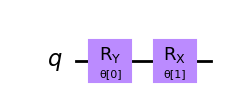

In [4]:
from qiskit.circuit import Parameter, ParameterVector
#Parameter이 간단한 string으로 초기화됩니다
parameter_0 = Parameter('θ[0]')
parameter_1 = Parameter('θ[1]')
circuit = QuantumCircuit(1)
#초기화된 Parameter을 Rx와 Ry 게이트의 회전 각도 변수(rotation angle argument)로 넣을 수 있습니다
circuit.ry(theta = parameter_0, qubit = 0)
circuit.rx(theta = parameter_1, qubit = 0)
circuit.draw('mpl')

같은 매개변수가 같은 회로에서 여러 번 사용될 수 있습니다.  
위의 회로를 고려하여, 다른 게이트에 동일한 매개변수를 사용하면 다음과 같습니다.

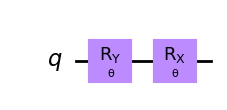

In [5]:
parameter = Parameter('θ')
circuit = QuantumCircuit(1)
circuit.ry(theta = parameter, qubit = 0)
circuit.rx(theta = parameter, qubit = 0)
circuit.draw('mpl')

편의를 위해 Qiskit의 ParameterVector 클래스를 사용할 수도 있습니다.
이 클래스는 매개변수 여러 개를 한번에 생성할 수 있게 합니다.  
아래의 RealAmplitudes 회로를 봅시다.
회로는 매개변수화된 RY 게이트와 얽힘 게이트인 CX 게이트의 레이어로 이루어져 있습니다.
RealAmplitudes variational 형태는 양자 머신러닝의 classification에서 자주 사용되며, qiskit circuit library에서 찾을 수 있습니다.

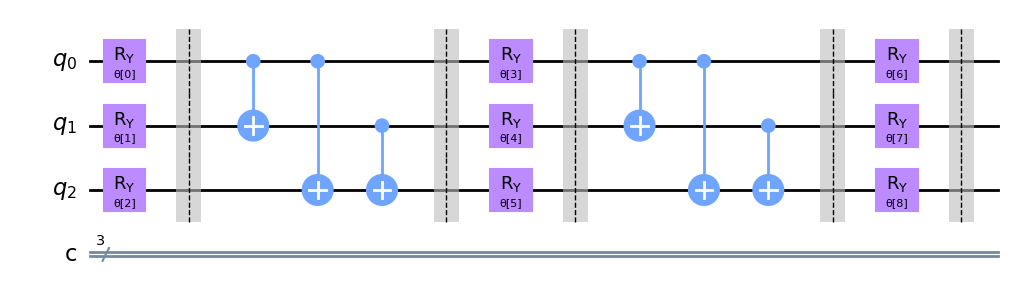

In [6]:
#레이어와 큐비트 수를 세팅합니다
n=3
num_layers = 2

#ParameterVector는 특정한 정수 벡터길이의 string으로 초기화됩니다
parameters = ParameterVector('θ', n*(num_layers+1))


circuit = QuantumCircuit(n, n)
for layer in range(num_layers):
    #위에서 만든 parameters를 이용하여 매개변수화된 Ry gate를 추가합니다
    for i in range(n):
        circuit.ry(parameters[n*layer+i], i)
    circuit.barrier()

    #얽힌 CNOT gate를 추가합니다
    for i in range(n):
        for j in range(i):
                circuit.cx(j,i)
    circuit.barrier()

#매개변수화된 Ry gate 한 레이어를 추가합니다
for i in range(n):
    circuit.ry(parameters[n*num_layers+i], i)
circuit.barrier()

circuit.draw('mpl')

In [7]:
## 양자 회로의 매개변수들을 확인할 수 있습니다

print(circuit.parameters)

ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8])])


### 매개변수에 값 할당하기
매개변수화된 회로는 매개변수에 고정된 값을 할당받지 못하면 실행될 수 없습니다.
값을 할당하기 위해 다음의 방법을 사용할 수 있습니다.  
```
assign_parameters(parameters, inplace = False)
bind_parameters(values)
```
`bind_parameters`는 회로의 매개변수에 숫자 값을 할당해 항상 새로운 회로를 만듭니다.
`assign_parameters`는 숫자 값이나 다른 매개변수 표현의 대체 매개변수를 할당할 수 있습니다.

{ParameterVectorElement(θ[0]): 0.09767211400638387, ParameterVectorElement(θ[1]): 0.6842330265121569, ParameterVectorElement(θ[2]): 0.4401524937396013, ParameterVectorElement(θ[3]): 0.12203823484477883, ParameterVectorElement(θ[4]): 0.4951769101112702, ParameterVectorElement(θ[5]): 0.034388521115218396, ParameterVectorElement(θ[6]): 0.9093204020787821, ParameterVectorElement(θ[7]): 0.2587799816000169, ParameterVectorElement(θ[8]): 0.662522284353982}


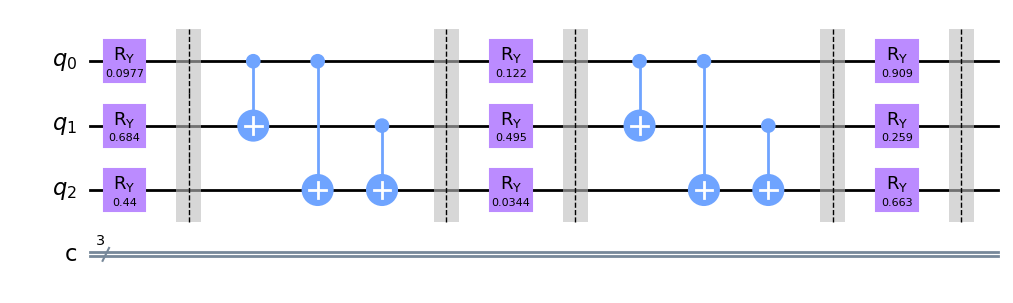

In [8]:
#매개변수 값들를 bind하기 위해 parameter dictionary를 만듭니다
param_dict = {parameter: np.random.random() for parameter in parameters}
print(param_dict)
#assign_parameters를 사용해 매개변수를 할당합니다
bound_circuit = circuit.assign_parameters(parameters = param_dict)
bound_circuit.draw('mpl')

이어 다음 회로에서 우리는 원래 회로의 매개변수를 다른 매개변수 표현으로 바꿀 수 있습니다.

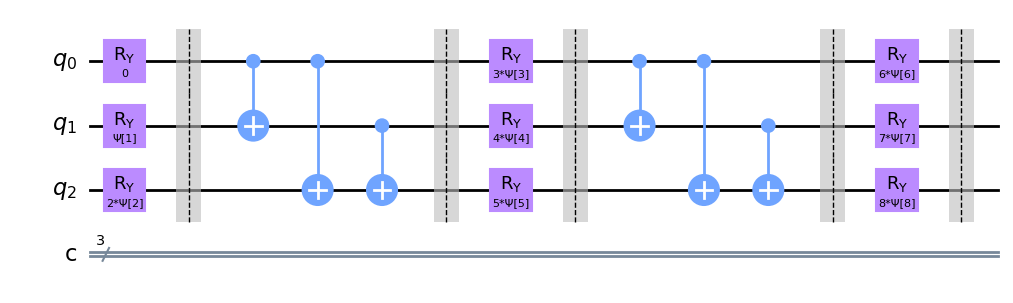

In [9]:
new_parameters = ParameterVector('Ψ',9)
new_circuit = circuit.assign_parameters(parameters = [k*new_parameters[k] for k in range(9)])
new_circuit.draw('mpl')

이제 회로를 양자 컴퓨터에서 실행해봅시다. 매개변수화된 회로를 할당되지 않은 매개변수로 실행햐려고 하는 것은 에러를 발생시킬 것입니다.

In [16]:
# 밑의 코드는 할당되지 않은 매개변수가 있는 'circuit'때문에 에러가 발생합니다
# result = simulator.run(circuit).result()

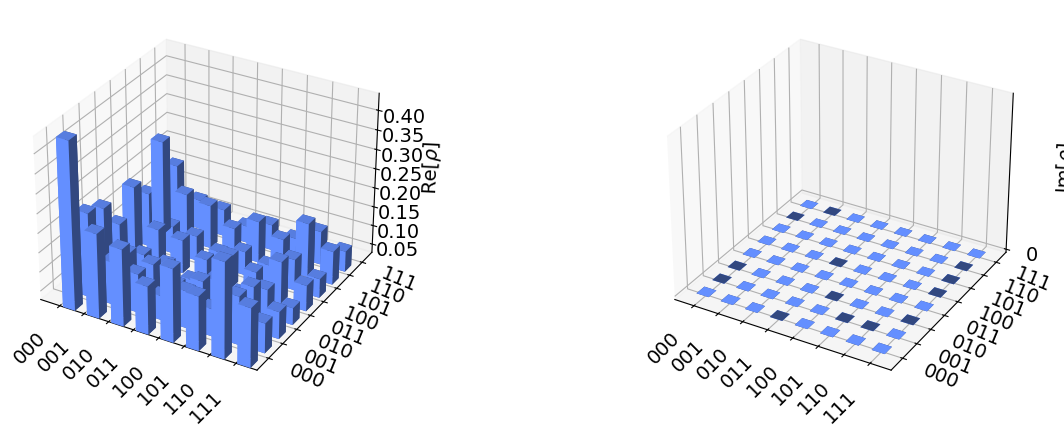

In [211]:
# Aer's statevector simulator로 값이 할당된 매개변수 회로를 실행해봅시다
simulator = Aer.get_backend('statevector_simulator')
result = simulator.run(bound_circuit).result()
statevector = result.get_statevector(bound_circuit)
plot_state_city(statevector)

## 문제 1 : Ansatz Circuit 만들기

위의 예제와 비슷한 방법으로 매개변수화된 회로를 만들어보겠습니다.
다음 회로와 같은 매개변수화된 회로를 만드는 코드를 작성하세요.  
Rz gate의 매개변수는 'θ'이고, Ry gate의 매개변수는 'Ψ'입니다.  
![Prob1](images/Prob1.png)

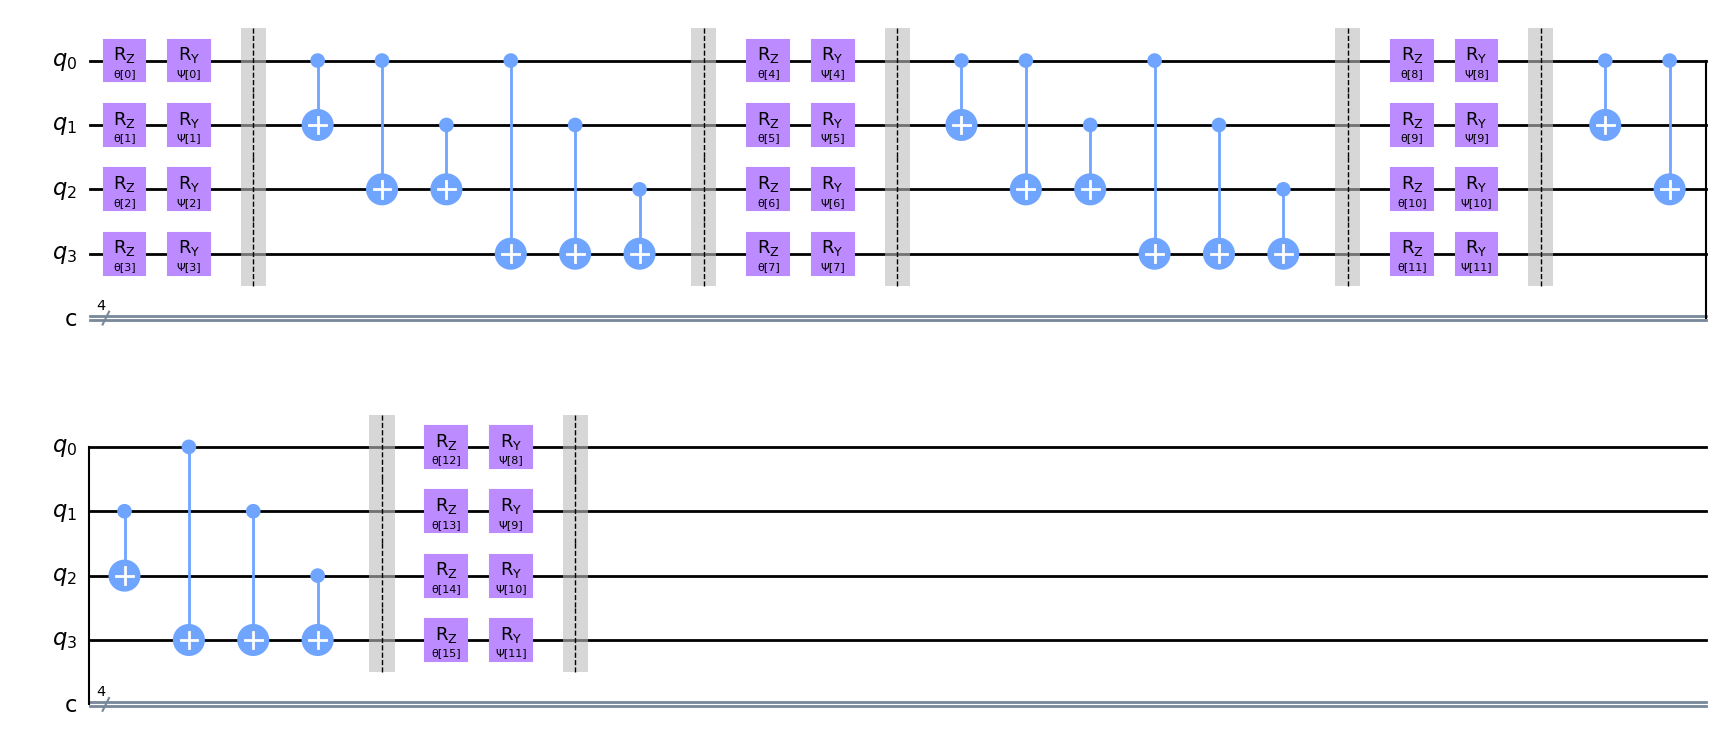

In [214]:
from qiskit.circuit import Parameter, ParameterVector
#레이어와 큐비트 수를 세팅합니다
n=4
num_layers = 3


########## Write your code below this line ##########
# ParameterVector는 특정한 정수 벡터길이의 string으로 초기화됩니다
# ParameterVector를 이용하여 θ와 Ψ 매개변수를 생성합니다
zparam = ParameterVector("θ", 16)
yparam = ParameterVector("Ψ", 12)

######### Do not change the code below here #########

circuit = QuantumCircuit(n, n)
    
########## Write your code below this line ##########
# 위에서 만든 parameters를 이용하여
# 매개변수화된 Ry gate, Rz gate, CNOT gate, barrier를추가합니다
for _ in range(num_layers):
    for i in range(n):
        circuit.rz(zparam[i + _*n], i)
        circuit.ry(yparam[i + _*n], i)
    circuit.barrier([0,1,2,3])
    
    for i in range(n):
        for j in range(0, i):
            circuit.cx(j, i)
        
    circuit.barrier([0,1,2,3])

for i in range(4):
    circuit.rz(zparam[-i-1], 3-i)
    circuit.ry(yparam[-i-1], 3-i)
circuit.barrier([0,1,2,3])
    
######### Do not change the code below here #########
answer1 = circuit
circuit.draw('mpl')

In [215]:
# Grader Cell: Run this to submit your answer

from qff_ku_grader.challenges.qff_ku2023 import grade_challenge9a

grade_challenge9a(answer1)


Oops 😕! Your answer is incorrect


Ansatz 회로는 활발히 연구중이며, Hardware-effocient ansatz와 Unitary-Clustered Ansatz는 VQA에서 자주 쓰이는 Ansatz입니다.
문제 1의 회로는 Hardware-Efficient ansatz 중 하나로, 여러분은 최적화에 사용되는 Ansatz 회로를 만드신 것입니다!  
이제 ansatz를 이용해 최적화 알고리즘을 생성해봅시다. 

# Section 2

이제 Variational Quantum Algorithm을 이용하여 최적화문제를 풀어봅시다!  
대표적인 VQA인 Quantum Approximate Optimization Algorithm을 이용하여 MaxCut Problem을 풀어보겠습니다.

### Quadratic Programs
우선 MaxCut 문제를 알고 어떻게 Quadratic 프로그램을 만들것인지 배워봅시다.

## MaxCut 
MaxCut 문제에서 input은 그래프(많은 경우 가중치가 있는 그래프)이며,
그래프의 vertex들을 두 개의 서로소 집합으로 나눕니다.
vertex들을 나누기 위해 edge를 Cut 할 때에, 최대한 가중치(weight)가 많은 edge를 Cut하는 것이 핵심이며, edge의 가중치들은 누적됩니다.
가중치가 높은 edge를 최대로 Cut하여 두 개의 서로소 집합으로 vertex를 나누는 MaxCut 문제는 NP - Hard 문제이기도 합니다. 
아래 그림의 Graph에서는 빨간색 edge들을 Cut하여 vertex를 연한 파랑색과 진한 파랑색의 서로소 집합으로 나누었습니다. 
![maxcut](images/maxcut.png)


$G=(V,E)$ 라는 그래프가 $n$ 개의 vertex을 가진 가중치가 있는 그래프라고 합시다. 
vertex $v_1, \dots, v_n$에 번호를 부여하고 **각 vertex에 값 0 또는 1을 할당하면 벡터 $x \in \{0,1\}^n$** 로 그래프의 Cut을 식별할 수 있습니다.
Cut $x$의 가중치는 비용 함수에 의해 결정됩니다.
비용함수는 다음과 같습니다.  

$$
C(x) = \sum_{i,j=1}^n W_{ij} x_i (1-x_j)
$$
  
여기서 $W_{ij} = W_{ji}$는 vertex $v_i$와 $v_j$를 연결하는 edge의 가중치를 결정하며, $v_i$와 $v_j$가 edge에 의해 연결되지 않은 경우 $W_{ij} = 0$입니다.
각 edge의 가중치는 $x_i \neq x_j$인 경우에만 합에 정확히 한 번 기여한다는 것을 쉽게 알 수 있습니다.  

아래에 정의된 'graphs' 사전에는 탐색할 수 있는 여러 그래프 인스턴스가 포함되어 있습니다.
각 그래프의 이름 끝에는 사용되는 가중치의 종류가 지정됩니다.

In [33]:
for key in graphs.keys():
    print(key)

barbell_unweighted
barbell_float(-1_1)
barbell_int(-5_5)
circular_small_unweighted
circular_small_float(-1_1)
circular_small_int(-5_5)
circular_large_unweighted
circular_large_float(-1_1)
circular_large_int(-5_5)
fully_connected_small_unweighted
fully_connected_small_float(-1_1)
fully_connected_small_int(-5_5)
fully_connected_large_unweighted
fully_connected_large_float(-1_1)
fully_connected_large_int(-5_5)


'networkx' 모듈을 사용하여 그래프 인스턴스를 하나 더 만들어서 Dictionary에 추가해 보겠습니다. 
아래 위젯을 사용하여 서로 다른 그래프 인스턴스의 Cut을 탐색할 수 있습니다. 
두 그룹의 vertices은 각각 밝은 파란색과 어두운 파란색으로 표시되고, 서로 다른 그룹의 vertices을 연결하는 (따라서 절단된 무게에 기여하는)edge는 빨간색으로 표시됩니다.

In [36]:
graph = nx.Graph()
#nodes와 edges 추가
graph.add_nodes_from(np.arange(0,6,1))
edges = [(0,1,2.0),(0,2,3.0),(0,3,2.0),(0,4,4.0),(0,5,1.0),(1,2,4.0),(1,3,1.0),(1,4,1.0),(1,5,3.0),(2,4,2.0),(2,5,3.0),(3,4,5.0),(3,5,1.0)]
graph.add_weighted_edges_from(edges)
graphs['custom'] = graph
#Display widget
display_maxcut_widget(graphs['custom'])

CytoscapeWidget(cytoscape_layout={'name': 'cola'}, cytoscape_style=[{'selector': 'node', 'css': {'background-c…

Output()

## 문제 2 : MaxCut

위에서 새로 정의된 그래프의 경우, 최대 Cut을 찾아서 grader에 '$x= $\[$x_0, x_1, ..., x_n $\]' 비트의 목록으로 전달합니다. 
가능한 모든 비트열에 대한 비용 함수 값의 막대 그래프를 표시하기 위해, 특정 비트열에 대한 최대 컷 비용 함수 값을 계산해야 합니다.  
주어진 칸에 MaxCut의 비용함수를 코드로 나타내보세요.
numpy 행렬 'weight_ matrix'는 $W$를 의미하며, 'weight_ matrix[i,j]'를 통해 $W_{ij}$ 요소에 접근할 수 있습니다.

In [40]:
def maxcut_cost_fn(graph: nx.Graph, bitstring: List[int]) -> float:
    """
    Computes the maxcut cost function value for a given graph and cut represented by some bitstring
    Args:
        graph: The graph to compute cut values for
        bitstring: A list of integer values '0' or '1' specifying a cut of the graph
    Returns:
        The value of the cut
    """
    #그래프의 가중치를 얻습니다
    weight_matrix = nx.adjacency_matrix(graph).toarray()
    size = weight_matrix.shape[0]
    value = 0.
    
    ############INSERT YOUR CODE TO COMPUTE THE CUT VALUE HERE#############
    sep = list()
    for bdx in range(len(bitstring)):
        if bitstring[bdx]: sep.append(bdx)
    
    for bdx in sep:
        for i in range(len(bitstring)):
            if bdx == i:
                continue
            value += weight_matrix[bdx, i]
    
    for bdx1 in sep:
        for bdx2 in sep:
            value -= weight_matrix[bdx1, bdx2]
    
    #######################################################################    

    return value

def plot_maxcut_histogram(graph: nx.Graph) -> None:
    """
    Plots a bar diagram with the values for all possible cuts of a given graph.
    Args:
        graph: The graph to compute cut values for
    """
    num_vars = graph.number_of_nodes()
    #bitstring과 Cut value 에 대한 리스트를 만듭니다
    bitstrings = ['{:b}'.format(i).rjust(num_vars, '0')[::-1] for i in range(2**num_vars)]
    values = [maxcut_cost_fn(graph = graph, bitstring = [int(x) for x in bitstring]) for bitstring in bitstrings]
    #가장 큰 Cut value로 리스트를 정렬합니다
    values, bitstrings = zip(*sorted(zip(values, bitstrings)))
    #막대그래프를 그립니다
    bar_plot = go.Bar(x = bitstrings, y = values, marker=dict(color=values, colorscale = 'plasma', colorbar=dict(title='Cut Value')))
    fig = go.Figure(data=bar_plot, layout = dict(xaxis=dict(type = 'category'), width = 1500, height = 600))
    fig.show()

In [41]:
plot_maxcut_histogram(graph = graphs['custom'])

In [43]:
# 가장 높은 값이 나온 bitstring을 입력해주세요. 가장 높은 값이 나온것이 여러개라면
# 그 중 하나만 입력해주시면 됩니다.
bitstring = [0,1,0,0,1,1] #DEFINE THE CORRECT MAXCUT BITSTRING HERE

# Grader Cell: Run this to submit your answer

from qff_ku_grader.challenges.qff_ku2023 import grade_challenge9b

grade_challenge9b(bitstring)


Congratulations 🎉! Your answer is correct.


### Quadratic Programs
Quadratic Program(QP)는 **목적함수(objective function)가 이차식(convex quadratic)**
이고, 제약함수(constraint functions)가 모두 affine인 **convex optimization problem**입니다. General quadratic program은 다음과 같은 형태로 표현될 수 있습니다.<br>
<br>
$$
\begin{align}
\text{minimize} &&x^T Q x + c^T x &&\\
&& && \\
\text{subject to} &&Ax \leq b  &&\\
&& x^TQ_ix + a_i^Tx \leq r_i \\
&& l_j \leq x_j \leq u_j \\
\end{align}
$$  
<br>
여기서 $Q \in \mathbb{R}^{n \times n}$인 $n \times n$-matrix이고 $c \in \mathbb{R}^n$는 목적 함수의 2차 및 선형 부분을 지정하는 실수 값 벡터입니다. 최적화 변수 $x_i, i \in \{1, \dots, n\}$는 당면한 문제에 따라 이진, 정수 또는 실수 값일 수 있습니다.

Qiskit에서는 qiskit_optimization 모듈에 위치한 QuadraticProgram 클래스로 2차 프로그램을 생성할 수 있습니다. 새로운 모델을 생성하려면 원하는 문제 이름으로 이니셜라이저를 호출하기만 하면 됩니다.

In [51]:
from qiskit_optimization import QuadraticProgram
quadratic_program = QuadraticProgram('sample_problem')
print(quadratic_program.export_as_lp_string())

\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: sample_problem

Minimize
 obj:
Subject To

Bounds
End



우리는 'binary_var', 'integer_var', 'continuous_var'의 방법을 이용하여 이진수, 정수 또는 연속하는 최적화 변수들을 추가할 수 있습니다. Quadratic Program 에 추가되는 모든 변수는 이름으로 지정됩니다. 우리는 또한 'lowerbound'와 'upperbound' 인수를 사용하여 정수 및 연속 변수에 대한 하한값, 상한값을 지정할 수 있습니다.

In [52]:
quadratic_program.binary_var(name = 'x_0')
quadratic_program.integer_var(name = 'x_1')
quadratic_program.continuous_var(name = 'x_2', lowerbound = -2.5, upperbound = 1.8)

<Variable: -2.5 <= x_2 <= 1.8 (continuous)>

목적함수는 최소화 문제인지 최대화 문제인지에 따라 다른 방법을 사용합니다. 2차항, 선형항(1차항), 상수항은 list, matrix 또는 dictionary 중 하나로 지정할 수 있습니다. <br>

마지막으로 Quadratic Program을 읽을 수 있는 형식으로 print하려면 'export_as_lp_string' 방법을 사용합니다.

In [57]:
quadratic = [[0,1,2],[3,4,5],[0,1,2]]
linear = [10,20,30]
quadratic_program.minimize(quadratic = quadratic, linear = linear, constant = -5)
print(quadratic_program.export_as_lp_string())

\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: sample_problem

Minimize
 obj: 10 x_0 + 20 x_1 + 30 x_2 + [ 8 x_0*x_1 + 4 x_0*x_2 + 8 x_1^2 + 12 x_1*x_2
      + 4 x_2^2 ]/2 -5
Subject To

Bounds
 0 <= x_0 <= 1
 -2.500000000000 <= x_2 <= 1.800000000000

Binaries
 x_0

Generals
 x_1
End



### Quadratic Program을 이용한 MaxCut
우리는 모든 MaxCut 문제를 Quadratic Program으로 공식화할 수 있습니다! 대칭 가중치 행렬(symmetric weight matrix) $W$의 MaxCut 문제에 대한 비용 함수를 다시 떠올려봅시다.  
$$
C(x) = \sum_{i,j=1}^n W_{ij} x_i (1-x_j)입니다.
$$  
이것은 분명히 2차 함수이며 Quadratic Program의 표준 형태로 재구성할 수 있습니다.  <br>
$$
\begin{align}
\sum_{i,j=1}^n W_{ij} x_i (1-x_j) &= \sum_{i,j=1}^n W_{ij} x_i - W_{ij} x_i x_j \\
&= \sum_{i=1}^n \left( \sum_{j=1}^n W_{ij} \right) x_i - \sum_{i,j = 1}^n W_{ij}x_i x_j \\
&= c^T x + x^T Q x, \\
\end{align}
$$  
다음과 같이 정의된 $Q$ 및 $c$의 경우
$$
Q_{ij} = -W_{ij} \qquad c_i = \sum_{j=1}^n W_{ij}입니다.
$$  
이렇게 2차 목적함수와 이진 변수를 이용하여 다른 변수 제약이 없는 최적화 인스턴스를 얻었습니다.
이 형태의 Quadratic Program을 Quadratic Unconstrained Binary Optimization instance 또는 줄여서 QUBO라고도 합니다. 

## 문제 3: MaxCut to QUBO

다음 함수는 그래프로 정의된 MaxCut 문제로부터 Quadratic Program을 구성해야 합니다.  
앞서 설명한 식들을 이용하여 코드를 완성하세요.
Quadratic Program에 이진 변수를 추가해야 하며, 이 프로그램의 이름은 x_0, x_1, ..., x_n입니다. 
가중치 행렬 $W$를 'weight_matrix', QUBO 행렬 $Q$를 'qubo_matrix'라고 합니다.

In [65]:
def quadratic_program_from_graph(graph: nx.Graph) -> QuadraticProgram:
    """Constructs a quadratic program from a given graph for a MaxCut problem instance.
    Args:
        graph: Underlying graph of the problem.
    Returns:
        QuadraticProgram
    """
    #Get weight matrix of graph
    weight_matrix = nx.adjacency_matrix(graph)
    shape = weight_matrix.shape
    size = shape[0]
    #Build qubo matrix Q from weight matrix W
    qubo_matrix = np.zeros((size, size))
    qubo_vector = np.zeros(size)
    for i in range(size):
        for j in range(size):
            qubo_matrix[i, j] -= weight_matrix[i, j]
    for i in range(size):
        for j in range(size):
            qubo_vector[i] += weight_matrix[i,j]


    quadratic_program = QuadraticProgram('quadratic_program')
    ###############INSERT YOUR CODE HERE#####################
    for var_num in range(size):
        quadratic_program.binary_var(name = f"x_{var_num}") 

    quadratic_program.maximize(quadratic = qubo_matrix, linear = qubo_vector)
    
    ########################################################
    return quadratic_program

In [66]:
quadratic_program = quadratic_program_from_graph(graphs['custom'])
print(quadratic_program.export_as_lp_string())

\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: quadratic_program

Maximize
 obj: 12 x_0 + 11 x_1 + 12 x_2 + 9 x_3 + 12 x_4 + 8 x_5 + [ - 8 x_0*x_1
      - 12 x_0*x_2 - 8 x_0*x_3 - 16 x_0*x_4 - 4 x_0*x_5 - 16 x_1*x_2 - 4 x_1*x_3
      - 4 x_1*x_4 - 12 x_1*x_5 - 8 x_2*x_4 - 12 x_2*x_5 - 20 x_3*x_4 - 4 x_3*x_5
      ]/2
Subject To

Bounds
 0 <= x_0 <= 1
 0 <= x_1 <= 1
 0 <= x_2 <= 1
 0 <= x_3 <= 1
 0 <= x_4 <= 1
 0 <= x_5 <= 1

Binaries
 x_0 x_1 x_2 x_3 x_4 x_5
End



In [67]:
# Grader Cell: Run this to submit your answer

from qff_ku_grader.challenges.qff_ku2023 import grade_challenge9c

grade_challenge9c(quadratic_program)


Congratulations 🎉! Your answer is correct.


Grader

## Quantum Approximate Optimization Algorithm (QAOA)
Qiskit에 구현된 양자 근사 최적화 알고리즘(QAOA)을 사용하여 QAOA의 Variational Form을 구현하고 MaxCut 문제를 해결해봅시다!

### QAOA Variational Form 
QAOA의 Variational Form은 다음과 같은 구조를 가지고 있습니다.  
![QAOA_Ansatz](images/QAOA_Ansatz.png)


$H_C$는 최적화 문제의 비용 함수를 인코딩하는 비용 해밀토니안이고, $H_M$는 mixer 해밀토니안입니다. <br>
QAOA에서 초기 준비 상태는 동일 중첩 상태입니다.  
$$
\vert + \rangle = \sum_{x \in \{0,1\}^{n}} \frac{1}{\sqrt{2^n}} \vert x \rangle
$$  
mixer 해밀턴은 모든 큐비트에서 단일 파울리 $X$ 연산자의 합으로 정의됩니다.  
$$
H_M = \sum_{i=1}^n{X_i}입니다.
$$  
대응하는 행렬 $Q$를 갖는 QUBO 인스턴스의 경우, 우리는 비용 함수 $C(x)$를 비용 해밀턴 $H_C$로 인코딩하려고 합니다. 즉, 우리는 다음과 같은 연산자 $H_C$를 찾으려고 합니다.  
$$
H_C \vert x \rangle = \left( x^T Q x + c^T x \right) \vert x \rangle = \left( \sum_{i,j=1}^n x_i Q_{ij} x_j + \sum_{i=1}^n c_ix_i \right) \vert x \rangle
$$  
모든 계산 기저 상태 $x \in \{0,1\}^n$.<br>
그 사실을 이용해서  
$$
Z_i\vert x \rangle = (-1)^{x_i} \vert x \rangle = \left( 1-2x_i \right) \vert x \rangle = \frac{\mathbb{I}-Z_i}{2}\vert x \rangle,
$$  
여기서 $\mathbb{I}$는 단위 연산자를 나타내고 큐비트 $i$에 대한 파울리-Z 행렬인 $Z_i$를 나타냅니다. 
비용 함수식 $C(x)$에서 \frac{\mathbb{I}-Z_i}{2}$로 대체 $x_i \를 수행하여 파울리-Z 연산자의 합으로 $H_C$를 쓸 수 있습니다. 
이것은 $H_C$에 대해 다음과 같은 표현을 산출합니다.  <br>
$$
H_C = \sum_{i,j=1}^n \frac{1}{4}Q_{ij} Z_iZ_j - \sum_{i=1}^n \frac{1}{2} \left(c_i + \sum_{j=1}^n Q_{ij} \right) Z_i +  \left( \sum_{i,j=1}^n \frac{Q_{ij}}{4} + \sum_{i=1}^n \frac{c_i}{2} \right)
$$  
두 해밀토니안을 지수화하여, 우리는 비용 계층에서 $R_Z$ 및 $R_{ZZ}$ 게이트와 mixer 계층에서 $R_X$ 게이트로 구성된 Variational Form을 얻습니다.  
$$
e^{- i \beta H_M} = \prod_{i=1}^n R_{X_i}(2\beta) \quad \quad e^{- i \gamma H_C} = \prod_{i,j=1 \\ i \neq j}^n R_{Z_iZ_j} \left( \frac{1}{2} Q_{ij} \gamma \right) \prod_{i=1}^nR_{Z_i} \left( \left( c_i + \sum_{j=1}^n Q_{ij} \right) \gamma \right)
$$  


## 문제 4: QAOA Variational Form
2차 프로그램과 매개 변수 $p$를 입력으로 하고 $p$ 레이어로 해당 QAOA 회로를 출력으로 생성하는 함수를 작성합니다. 
함수의 기본 구성은 아래에 나와 있지만 비용 레이어와 믹서 레이어가 적용되는 부분을 작성해야 합니다. 
위의 마지막 방정식에서 설명한 대로 회전 게이트의 각도를 계산해야 합니다. 
아래 코드에서 우리는 qubo 행렬 $Q$를 'qubo_matrix'라고 부르고 벡터 $c$를 'qubo_linearity'라고 부릅니다. 
회로에 측정값은 포함하지 않습니다.

In [203]:
def qaoa_circuit(qubo: QuadraticProgram, p: int = 1):
    """
    Given a QUBO instance and the number of layers p, constructs the corresponding parameterized QAOA circuit with p layers.
    Args:
        qubo: The quadratic program instance
        p: The number of layers in the QAOA circuit
    Returns:
        The parameterized QAOA circuit
    """
    size = len(qubo.variables)
    qubo_matrix = qubo.objective.quadratic.to_array(symmetric=True)
    qubo_linearity = qubo.objective.linear.to_array()

    #Prepare the quantum and classical registers
    qaoa_circuit = QuantumCircuit(size,size)
    #Apply the initial layer of Hadamard gates to all qubits
    qaoa_circuit.h(range(size))

    #Create the parameters to be used in the circuit
    gammas = ParameterVector('gamma', p)
    betas = ParameterVector('beta', p)

    #Outer loop to create each layer
    for i in range(p):

        #################INSERT YOUR CODE HERE##############################
        #비용 레이어에서 R_Z 회전 게이트를 적용하세요
        for m in range(size):
            qsum = 0
            for n in range(size):
                qsum += qubo_matrix[m, n]
            qaoa_circuit.rz(gammas[i]*(qubo_linearity[m] + qsum), m)
        
        ####################################################################
        
        #################INSERT YOUR CODE HERE##############################
        #비용 레이어에서 얽힘 큐비트 회전을 위해 R_ZZ 회전 게이트를 적용하세요
        for m in range(size):
            for n in range(size):
                if m == n:
                    continue
                qaoa_circuit.rzz(gammas[i] * (1/2) * qubo_matrix[m,n], m, n)
        
        ####################################################################
        
        #################INSERT YOUR CODE HERE##############################
        #모든 큐비트에 2*beta_i의 각도로 X 회전을 적용하세요
        
        for s in range(size):
            qaoa_circuit.rx(2 * betas[i], s)
        ####################################################################
        
            
    return qaoa_circuit

In [204]:
quadratic_program = quadratic_program_from_graph(graphs['custom'])
custom_circuit = qaoa_circuit(qubo = quadratic_program)

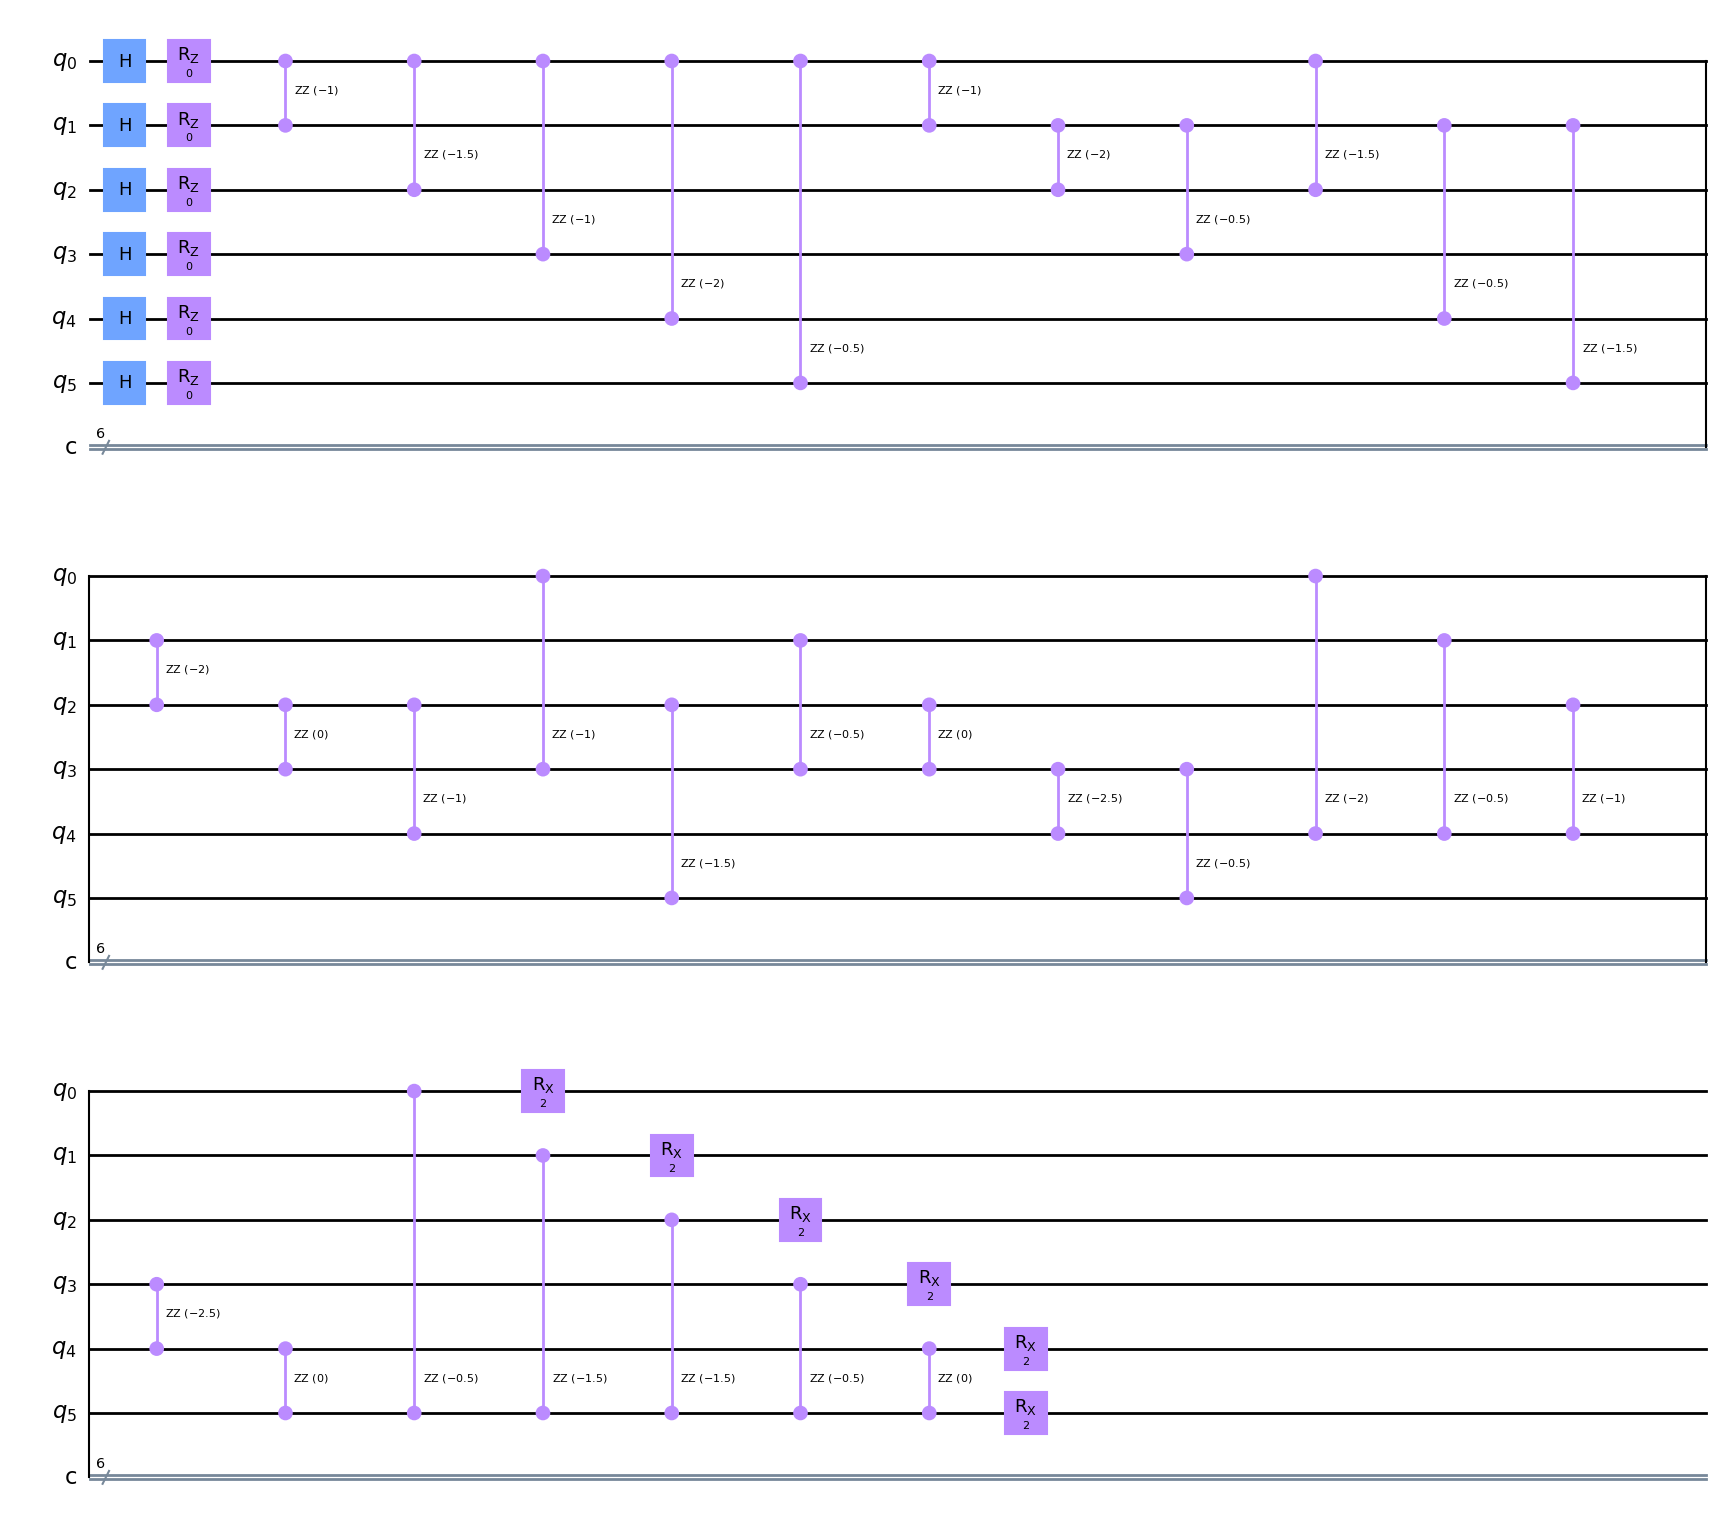

In [205]:
test = custom_circuit.assign_parameters(parameters=[1.0]*len(custom_circuit.parameters))
test.draw('mpl')

In [207]:
# Grader Cell: Run this to submit your answer

from qff_ku_grader.challenges.qff_ku2023 import grade_challenge9d

grade_challenge9d(test)


Congratulations 🎉! Your answer is correct.


## QAOA와 MinimumEigenSolver
문제를 성공적으로 푸셨다면 축하드립니다!
여러분은 양자컴퓨터에서 일반적인 QUBO 인스턴스와 MaxCut 문제를 해결할 수 있는 QAOA를 자체적으로 구현하셨습니다!  
이제 최적화 과정을 살펴봅시다. 아래에서, QAOA의 최적화 절차 몇가지를 테스트해봅시다. 

['MinimumEigenOptimizer'](https://qiskit.org/documentation/tutorials/optimization/3_minimum_eigen_optimizer.html) 객체는 2차 프로그램에서 큐비트 연산자로의 변환을 처리하는 최적화 과정을 위한 래퍼를 제공하고, QAOA와 같은 주어진 ['MinimumEigenSolver'](https://qiskit.org/documentation/stubs/qiskit.aqua.algorithms.MinimumEigensolver.html), 를 호출하여 해당 최적화 결과를 얻습니다. 초기화자는 최적화에 사용할 'MinimumEigenSolver'를 입력으로 받고, 2차 프로그램을 입력으로 하는 optimize 방법을 호출하여 최적화를 실행합니다. 이 모든 것을 종합하면, 우리는 몇 줄의 코드만으로 위에서 정의한 MaxCut 문제에 대한 해결책을 얻을 수 있습니다.

In [209]:
from qiskit.algorithms import QAOA
from qiskit_optimization.algorithms import MinimumEigenOptimizer
backend = Aer.get_backend('statevector_simulator')
qaoa = QAOA(optimizer = ADAM(), quantum_instance = backend, reps=1, initial_point = [0.1,0.1])
eigen_optimizer = MinimumEigenOptimizer(min_eigen_solver = qaoa)
quadratic_program = quadratic_program_from_graph(graphs['custom'])
result = eigen_optimizer.solve(quadratic_program)
print(result)

AttributeError: 'SparsePauliOp' object has no attribute 'primitive_strings'

보다시피, 최적화는 실제로 단지 몇 단계의 최적화 단계 내에서 최적을 찾을 수 있습니다. 우리는 또한 최적화된 상태 벡터를 플롯하여 매개 변수의 최적화가 끝난 후 어떤 비트열이 샘플링될 가능성이 더 높은지 확인할 수 있습니다.

In [210]:
def plot_samples(samples):
    """
    Plots a bar diagram for the samples of a quantum algorithm
    Args:
        samples
    """
    
    #확률로 샘플을 정렬합니다
    samples = sorted(samples, key = lambda x: x.probability)
    #Get list of probabilities, function values and bitstrings
    probabilities = [sample.probability for sample in samples]
    values = [sample.fval for sample in samples]
    bitstrings = [''.join([str(int(i)) for i in sample.x]) for sample in samples]
    #다이어그램을 그립니다
    sample_plot = go.Bar(x = bitstrings, y = probabilities, marker=dict(color=values, colorscale = 'plasma',colorbar=dict(title='Function Value')))
    fig = go.Figure(
        data=sample_plot, 
        layout = dict(
            xaxis=dict(
                type = 'category'
            )
        )
    )
    fig.show()

plot_samples(result.samples)

AttributeError: Attribute samples is not defined

### Higher values of $p$
$p$의 더 높은 값으로 QAOA는 이론적으로 양자 상태의 공간을 엄격하게 증가시키기 때문에 해밀턴 비용에 대해 더 나은 에너지 값으로 양자 상태에 도달할 수 있습니다. 즉, 만약
$$
M_p = \max_{\beta, \gamma \in \mathbb{R}^p} \langle \psi_p(\beta, \gamma) \vert H_C  \vert \psi_p(\beta, \gamma) \rangle
$$  
는 깊이 $p$의 QAOA 변형 형태로 도달할 수 있는 최대 에너지 값을 나타냅니다
$$
M_{p+1} \geq M_p입니다.
$$  
사실, 단열 정리(adiabatic theorem)를 사용하면, 무한 한계에서 최대 비용 함수 값 $C_{max}$에 도달할 수 있음을 증명할 수 있습니다
$$
\lim\limits_{p \to \inf} M_p = C_{max}.
$$  
단열 양자 컴퓨팅에 대한 연결은 QAOA가 좋은 최적화 결과를 얻을 것으로 기대할 수 있는 이유에 대한 정당화로 작용하지만, 무한 한계만 유지하며, 이는 다시 무한히 긴 양자 알고리즘에 해당합니다.
또한 레이어의 수에 따라 파라미터의 수가 증가하고, 파라미터를 더 도입할 때 글로벌 최적을 찾는 것이 점점 더 어려워진다는 점도 염두에 둘 필요가 있습니다.<br>
다음 그림은 $p$의 값을 증가시키기 위해 발견된 최적 QAOA 상태의 진화를 보여주며 회로 깊이가 QAOA 성능에 어떤 영향을 미치는지에 대한 몇 가지 아이디어를 제공합니다.

In [ ]:
optimizers = {
    'cobyla': COBYLA(),
    'slsqp': SLSQP(),
    'adam': ADAM()
}

최적화기기의 종류는 여러 개가 있지만 Qiskit에서 많이 쓰는 optimizer은 cobyla, slsqp, adam이 있습니다.
아래 코드에서는 cobyla를 이용하여 10번 최적화하는 과정을 보입니다. 

In [ ]:
graph_name = 'custom'
quadratic_program = quadratic_program_from_graph(graphs[graph_name])
#Create callback to record total number of evaluations
max_evals = 0
def callback(eval_count, params, mean, std_dev):
    global max_evals
    max_evals = eval_count

#Create empty lists to track values
energies = []
runtimes = []
num_evals=[]
    
#Run QAOA for different values of p
for p in range(1,10):
    print(f'Evaluating for p = {p}...')
    qaoa = QAOA(optimizer = optimizers['cobyla'], quantum_instance = backend, reps=p, callback=callback)
    eigen_optimizer = MinimumEigenOptimizer(min_eigen_solver = qaoa)
    start = time()
    result = eigen_optimizer.solve(quadratic_program)
    runtimes.append(time()-start)
    num_evals.append(max_evals)
    #Calculate energy of final state from samples
    avg_value = 0.
    for sample in result.samples:
        avg_value += sample.probability*sample.fval
    energies.append(avg_value)

#Create and display plots
energy_plot = go.Scatter(x = list(range(1,10)), y =energies, marker=dict(color=energies, colorscale = 'plasma'))
runtime_plot = go.Scatter(x = list(range(1,10)), y =runtimes, marker=dict(color=runtimes, colorscale = 'plasma'))
num_evals_plot = go.Scatter(x = list(range(1,10)), y =num_evals, marker=dict(color=num_evals, colorscale = 'plasma'))
fig = make_subplots(rows = 1, cols = 3, subplot_titles = ['Energy value', 'Runtime', 'Number of evaluations'])
fig.update_layout(width=1800,height=600, showlegend=False)
fig.add_trace(energy_plot, row=1, col=1)
fig.add_trace(runtime_plot, row=1, col=2)
fig.add_trace(num_evals_plot, row=1, col=3)
clear_output()
fig.show()

## 축하합니다!
여러분은 Variational Quantum Algorithm 전 과정을 explore 해보셨습니다! <br>
VQA는 Optimization과 Approximation에 유용하여 양자 컴퓨터의 성능을 활용하기에 무척 좋은 알고리즘입니다.<br>
VQA에는 QAOA 뿐만 아니라 [Variational Quantum Eigensolver](https://www.youtube.com/watch?v=Z-A6G0WVI9w) 등 다양한 변형 알고리즘이 있습니다.
또한, 처음에 언급했듯, VQA는 Neural Netwok와 비슷한 부분이 많습니다. [Quantum Neural Network](https://qiskit.org/ecosystem/machine-learning/tutorials/01_neural_networks.html)에도 관심이 있으시면 링크를 참고해보시기 바랍니다.<br>
수고하셨습니다!